In [1]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml

In [2]:
samples = [
    "2Mu2E_1000GeV_0p25GeV_0p002mm",
]

In [4]:
fileset = utilities.make_fileset(samples[0:3], 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                 max_files = -1,
                                )

In [7]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try: 
            output = coffea.util.load(filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
        except FileNotFoundError:
            print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample 2Mu2E_1000GeV_0p25GeV_0p002mm
Successfully opened file


In [11]:
channels = [
    "data_control_region_1muLj_cosmic_veto",
    "data_control_region_1egmLj_cosmic_veto",
    "data_control_region_1muLj_1egmLj_cosmic_veto",
    "data_control_region_2muLj_cosmic_veto",
]

histogram_collection = "mother_tracking_base"
processor_instance = sidm_processor.SidmProcessor(
    channels,
    [histogram_collection],
    unweighted_hist=False,
)

In [25]:
from collections import defaultdict
import math
import pandas as pd
from IPython.display import display, Markdown
import numpy as np

def categorize_mother_pdgid_sig(pdgid):
    abs_id = abs(pdgid)
    if abs_id == 11:
        return r"Electron"
    elif abs_id == 13:
        return r"Muon"
    elif abs_id == 32:
        return r"Dark Photon"
    elif abs_id in [1, 2, 3, 4, 5, 6, 9, 21]:
        return r"Quark/Gluon"
    else:
        return "Others"

def categorize_mother_pdgid_bkg(pdgid):
    abs_id = abs(pdgid)
    if abs_id == 11:
        return r"Electron"
    elif abs_id == 23:
        return r"Z Boson"
    elif abs_id == 24:
        return r"W Boson"
    elif abs_id in [111, 211]:
        return r"$\pi$0/$\pi$+"
    elif abs_id in [221, 223]:
        return r"$\eta$/$\omega$"
    elif abs_id in [511, 521, 531, 541]:
        return r"B Meson"
    elif abs_id in [411, 421, 423, 431]:
        return r"D Meson"
    elif abs_id in [1, 2, 3, 4, 5, 6, 9, 21]:
        return r"Quark/g"
    elif abs_id == 443:
        return r"J/$\Psi$"
    else:
        return "Others"

In [26]:
sample_category_dict = {}
sample_other_detail_dict = {}

num_samples = len(sample_category_dict)
ncols = 3
nrows = math.ceil(num_samples / ncols)

for sample in samples:
    counts = out[sample]["hists"]["fs_gen_mother_id"][channels[2], :].values(flow=False)
    category_counts = defaultdict(float)
    other_details = defaultdict(float)

    for pdgid, count in enumerate(counts):
        category = categorize_mother_pdgid_sig(pdgid)
        category_counts[category] += count
        if category == "Others":
            other_details[pdgid] += count

    sample_category_dict[sample] = category_counts
    sample_other_detail_dict[sample] = other_details

df = pd.DataFrame(sample_category_dict).T.fillna(0)
display(Markdown("## 🔹 Final State Mother Particle Category (Near LJ)"))
display(df)

df_other = pd.DataFrame(sample_other_detail_dict).T.fillna(0)
df_other = df_other.loc[:, (df_other > 0).any(axis=0)] 
df_other = df_other.loc[:, sorted(df_other.columns)] 

display(Markdown("## 🔸 Other Mother PDG ID Category"))
display(df_other)

## 🔹 Final State Mother Particle Category (Near LJ)

,Others,Quark/Gluon,Electron,Muon,Dark Photon
2Mu2E_1000GeV_0p25GeV_0p002mm,339.0,490.0,8096.0,367.0,53871.0


## 🔸 Other Mother PDG ID Category

,15,111,113,221,223,323,331,411,421,423,431,433,511,521,531
2Mu2E_1000GeV_0p25GeV_0p002mm,2.0,146.0,1.0,11.0,3.0,4.0,1.0,69.0,68.0,1.0,17.0,1.0,6.0,7.0,2.0


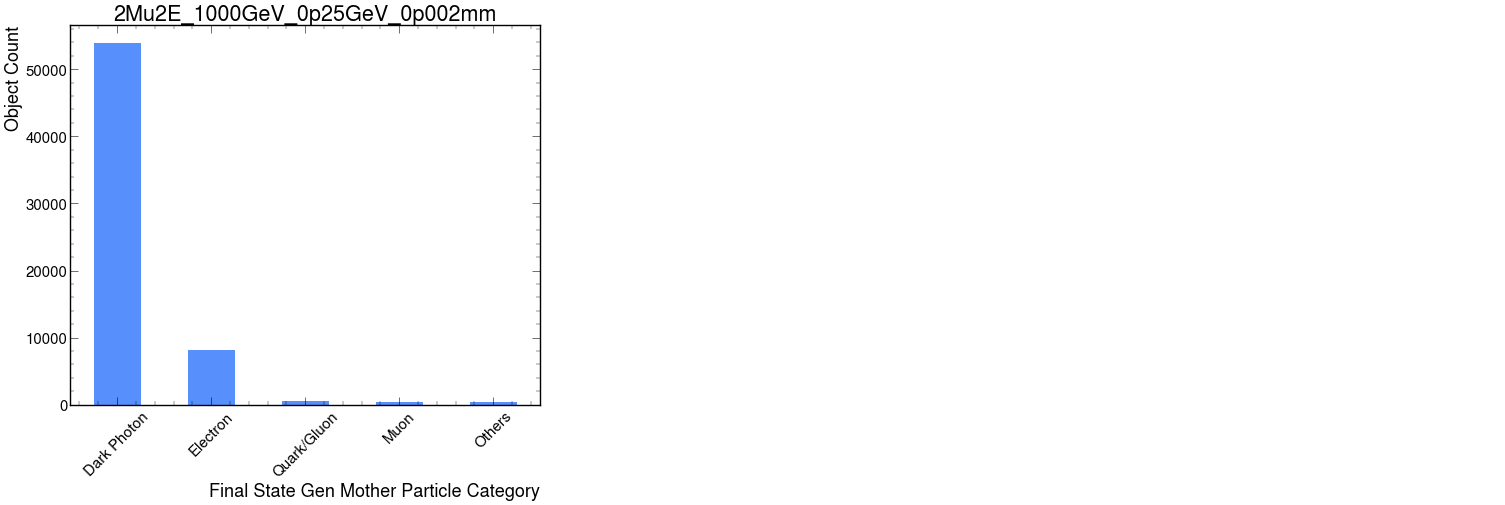

In [27]:
num_samples = len(sample_category_dict)
ncols = 3
nrows = math.ceil(num_samples / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*10, nrows*10), constrained_layout=True)

if isinstance(axs, np.ndarray):
    axs = axs.flatten()
else:
    axs = [axs]

for idx, (sample, category_counts) in enumerate(sample_category_dict.items()):
    ax = axs[idx]

    df_plot = pd.DataFrame.from_dict(category_counts, orient='index', columns=['count'])
    df_plot = df_plot.sort_values(by='count', ascending=False)

    df_plot.plot(kind='bar', legend=False, ax=ax)
    ax.set_title(sample)
    ax.set_ylabel("Object Count")
    ax.set_xlabel("Final State Gen Mother Particle Category")
    ax.tick_params(axis='x', rotation=45)

for j in range(idx + 1, len(axs)):
    axs[j].axis('off')

plt.show()

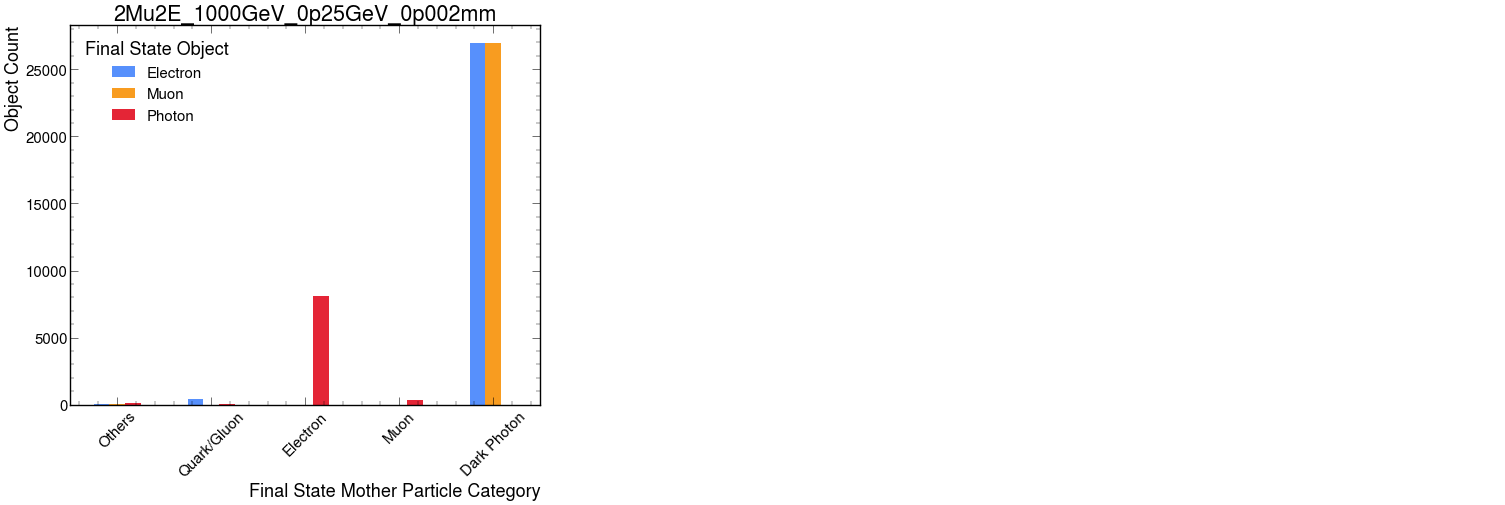

In [28]:
num_samples = len(sample_category_dict)
ncols = 3
nrows = math.ceil(num_samples / ncols)

object_types = {
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*10, nrows*10), constrained_layout=True)

if isinstance(axs, np.ndarray):
    axs = axs.flatten()
else:
    axs = [axs]

for idx, sample in enumerate(samples):
    ax = axs[idx]
    all_object_counts = defaultdict(dict)

    for obj_name, hist_key in object_types.items():
        counts = out[sample]["hists"][hist_key][channels[2], :].values(flow=False)
        for pdgid, count in enumerate(counts):
            category = categorize_mother_pdgid_sig(pdgid)
            all_object_counts[category][obj_name] = all_object_counts[category].get(obj_name, 0) + count

    df_plot = pd.DataFrame(all_object_counts).T.fillna(0)

    df_plot.plot(kind='bar', ax=ax)
    ax.set_title(sample)
    ax.set_ylabel("Object Count")
    ax.set_xlabel("Final State Mother Particle Category")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title="Final State Object")

# deactivate rest of empty space plots
for j in range(idx + 1, len(axs)):
    axs[j].axis('off')

plt.show()